# Pitch Classification in Baseball

### Goals
- Build a pitch classification model that takes pitch-level characteristics and predicts the pitch type label.
- Evaluate and compare the performance of different classification algorithms on the pitch data.
- Interpret model outputs and discuss the findings.


In [1]:
# Install Some Dependancies for the Lab
!pip install pybaseball --quiet
!pip install xgboost --quiet

In [2]:
from pybaseball import statcast

In [ ]:
# For this Lab, utilize pitching data from August 2025
data = statcast('2024-07-01', '2024-07-30')

In [4]:
# If you're on a Mac with a retina display, uncomment the below line for clean plotting
%config InlineBackend.figure_format = 'retina'

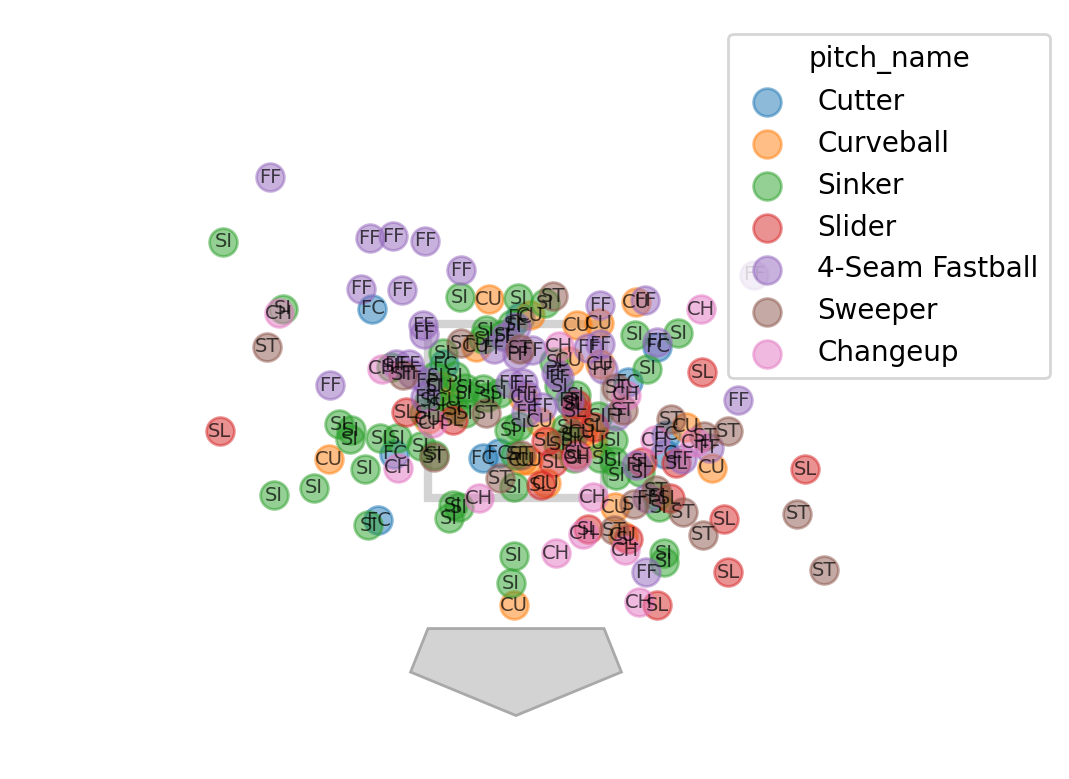

In [5]:
from pybaseball.plotting import plot_strike_zone
ax = plot_strike_zone(data.iloc[:200], colorby="pitch_name")

In [6]:
data['pitch_name'].value_counts()

,count
pitch_name,
4-Seam Fastball,38424
Sinker,18391
Slider,17423
Changeup,12756
Curveball,8956
Cutter,8582
Sweeper,8255
Split-Finger,3660
Knuckle Curve,2050


put pitches that are lower in value into other

In [7]:
data['pitch_name'].value_counts(normalize = True)

,proportion
pitch_name,
4-Seam Fastball,0.321532
Sinker,0.153896
Slider,0.145796
Changeup,0.106742
Curveball,0.074944
Cutter,0.071814
Sweeper,0.069078
Split-Finger,0.030627
Knuckle Curve,0.017154


## **Lab 2 Start**
- Import necessaary packages


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#data = statcast('2024-07-01', '2024-07-30')

This is a large query, it may take a moment to complete


  0%|          | 0/30 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
  3%|▎         | 1/30 [00:01<00:33,  1.15s/it]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch excepti

Display pitch name and counts for all pitches thrown

In [10]:
print(data['pitch_name'].value_counts())
print(data['pitch_name'].value_counts(normalize=True))

pitch_name
4-Seam Fastball    33776
Slider             16004
Sinker             15956
Changeup           10372
Cutter              8696
Sweeper             7405
Curveball           6313
Split-Finger        2873
Knuckle Curve       1864
Slurve               475
Knuckleball          189
Eephus               105
Other                 83
Screwball             41
Forkball              24
Slow Curve            14
Pitch Out              7
Name: count, dtype: int64
pitch_name
4-Seam Fastball    0.324155
Slider             0.153594
Sinker             0.153133
Changeup           0.099542
Cutter             0.083457
Sweeper            0.071067
Curveball          0.060587
Split-Finger       0.027573
Knuckle Curve      0.017889
Slurve             0.004559
Knuckleball        0.001814
Eephus             0.001008
Other              0.000797
Screwball          0.000393
Forkball           0.000230
Slow Curve         0.000134
Pitch Out          0.000067
Name: proportion, dtype: float64


Drop rows with NA

In [11]:
data = data.dropna(subset=['pitch_name'])

Group rare pitches- any pitch with value < 1000, into 'other' category

In [12]:
rare_pitches = data['pitch_name'].value_counts()[data['pitch_name'].value_counts() < 1000].index
data['pitch_name'] = data['pitch_name'].apply(lambda x: 'Other' if x in rare_pitches else x)

# Part 1: Pitch Classification Model

Select features relevant to pitch determination from full data set

In [13]:
#first, have to see which columns we have
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print("Full list of columns in the dataset:")
for col in data.columns:
    print(col)

Full list of columns in the dataset:
pitch_type
game_date
release_speed
release_pos_x
release_pos_z
player_name
batter
pitcher
events
description
spin_dir
spin_rate_deprecated
break_angle_deprecated
break_length_deprecated
zone
des
game_type
stand
p_throws
home_team
away_team
type
hit_location
bb_type
balls
strikes
game_year
pfx_x
pfx_z
plate_x
plate_z
on_3b
on_2b
on_1b
outs_when_up
inning
inning_topbot
hc_x
hc_y
tfs_deprecated
tfs_zulu_deprecated
umpire
sv_id
vx0
vy0
vz0
ax
ay
az
sz_top
sz_bot
hit_distance_sc
launch_speed
launch_angle
effective_speed
release_spin_rate
release_extension
game_pk
fielder_2
fielder_3
fielder_4
fielder_5
fielder_6
fielder_7
fielder_8
fielder_9
release_pos_y
estimated_ba_using_speedangle
estimated_woba_using_speedangle
woba_value
woba_denom
babip_value
iso_value
launch_speed_angle
at_bat_number
pitch_number
pitch_name
home_score
away_score
bat_score
fld_score
post_away_score
post_home_score
post_bat_score
post_fld_score
if_fielding_alignment
of_fielding_ali

Chose features relevant to pitching

In [14]:
features = [
    'release_speed', 'release_pos_x', 'release_pos_y', 'release_pos_z',
    'pfx_x', 'pfx_z', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'az',
    'effective_speed', 'release_spin_rate', 'release_extension',
    'spin_axis', 'plate_x', 'plate_z', 'arm_angle', 'p_throws'
]

Drop columns with missing data (NA) to clean up dataset

In [15]:
data = data.dropna(subset=features + ['pitch_name'])

Create the x and y component to understand feature and pitch name

In [16]:
X = data[features]
y = data['pitch_name']

Convert categorical pitch names into numeric labels for model

y encoded - contains the numerical representation of pitch names

In [17]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

Split data into train and test sets, scale data

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Convert 'p_throws' to numerical after splitting
X_train['p_throws'] = X_train['p_throws'].map({'R': 0, 'L': 1})
X_test['p_throws'] = X_test['p_throws'].map({'R': 0, 'L': 1})

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Part 2: Evaluate and compare using different algorithms

- For this section, I decided to evalute and compare the models using a baseline and logistic regression to understand a simple approach, then a random forest, and XG boost for a more extensive approach due to the structure of the data set and the non-linear overlap of pitch types.

- I decided against using a KNN model due to the size of the dataset training model as it typically is more accurate for small and simple problems. Moreover, I chose not to include SVM as pitch type classes are inbalanced and therefore do not have sharp splits meaning it is challenging to have a linear hyperplane existing.  I believe XG boost and random forest will do the best job at describing it.

**Model 1: Create a baseline model for comparison**
- use 'DummyClassifier', testing accuracy if we only guessed fastball as the outcome for every pitch as it was the most common in the data set.





In [20]:
print("\nTraining Baseline (Dummy Classifier - Most Frequent Class)...")
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)
acc_dummy = accuracy_score(y_test, y_pred_dummy)
print(f"Baseline (Dummy Classifier) Accuracy: {acc_dummy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_dummy, target_names=le.classes_, zero_division=0))


Training Baseline (Dummy Classifier - Most Frequent Class)...
Baseline (Dummy Classifier) Accuracy: 0.3270
Classification Report:
                  precision    recall  f1-score   support

4-Seam Fastball       0.33      1.00      0.49      6779
       Changeup       0.00      0.00      0.00      2044
      Curveball       0.00      0.00      0.00      1265
         Cutter       0.00      0.00      0.00      1708
  Knuckle Curve       0.00      0.00      0.00       388
          Other       0.00      0.00      0.00       189
         Sinker       0.00      0.00      0.00      3159
         Slider       0.00      0.00      0.00      3196
   Split-Finger       0.00      0.00      0.00       571
        Sweeper       0.00      0.00      0.00      1431

       accuracy                           0.33     20730
      macro avg       0.03      0.10      0.05     20730
   weighted avg       0.11      0.33      0.16     20730



If we were to guess that the pitch would be a fastball everytime, we would be correct 33% of the time

**Model 2: Logistic regression of multinomial pitch classifications**

Scale data for logistic regression



In [21]:
print("\nTraining Logistic Regression...")
logreg = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)
acc_logreg = accuracy_score(y_test, y_pred_logreg)
print(f"Logistic Regression Accuracy: {acc_logreg:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_logreg, target_names=le.classes_))


Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.7673
Classification Report:
                  precision    recall  f1-score   support

4-Seam Fastball       0.90      0.94      0.92      6779
       Changeup       0.71      0.74      0.72      2044
      Curveball       0.68      0.77      0.73      1265
         Cutter       0.63      0.51      0.56      1708
  Knuckle Curve       0.51      0.19      0.27       388
          Other       0.54      0.38      0.44       189
         Sinker       0.79      0.79      0.79      3159
         Slider       0.67      0.74      0.70      3196
   Split-Finger       0.63      0.47      0.54       571
        Sweeper       0.69      0.62      0.65      1431

       accuracy                           0.77     20730
      macro avg       0.67      0.62      0.63     20730
   weighted avg       0.76      0.77      0.76     20730



The logistic regression does not do a bad job (77%) but a more complex analysis should do better

**Model 2: Random Forest**

In [22]:
print("\nTraining Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_rf, target_names=le.classes_))


Training Random Forest...
Random Forest Accuracy: 0.9287
Classification Report:
                  precision    recall  f1-score   support

4-Seam Fastball       0.97      0.98      0.98      6779
       Changeup       0.93      0.96      0.94      2044
      Curveball       0.89      0.90      0.90      1265
         Cutter       0.86      0.82      0.84      1708
  Knuckle Curve       0.94      0.81      0.87       388
          Other       0.97      0.77      0.86       189
         Sinker       0.95      0.95      0.95      3159
         Slider       0.88      0.90      0.89      3196
   Split-Finger       0.94      0.76      0.84       571
        Sweeper       0.89      0.93      0.91      1431

       accuracy                           0.93     20730
      macro avg       0.92      0.88      0.90     20730
   weighted avg       0.93      0.93      0.93     20730



**Model 3: XGBoost**

In [23]:
print("\nTraining XGBoost...")
xgb_model = xgb.XGBClassifier(objective='multi:softprob', random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {acc_xgb:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred_xgb, target_names=le.classes_))


Training XGBoost...
XGBoost Accuracy: 0.9443
Classification Report:
                  precision    recall  f1-score   support

4-Seam Fastball       0.98      0.98      0.98      6779
       Changeup       0.95      0.97      0.96      2044
      Curveball       0.92      0.93      0.92      1265
         Cutter       0.88      0.86      0.87      1708
  Knuckle Curve       0.96      0.87      0.91       388
          Other       0.97      0.84      0.90       189
         Sinker       0.96      0.97      0.96      3159
         Slider       0.91      0.92      0.91      3196
   Split-Finger       0.96      0.87      0.91       571
        Sweeper       0.92      0.94      0.93      1431

       accuracy                           0.94     20730
      macro avg       0.94      0.91      0.93     20730
   weighted avg       0.94      0.94      0.94     20730



Comparing Performances

In [24]:
print("\nModel Comparison:")
print(f"Baseline (Dummy Classifier) Accuracy: {acc_dummy:.4f}")
print(f"Logistic Regression Accuracy: {acc_logreg:.4f}")
print(f"Random Forest Accuracy: {acc_rf:.4f}")
print(f"XGBoost Accuracy: {acc_xgb:.4f}")


Model Comparison:
Baseline (Dummy Classifier) Accuracy: 0.3270
Logistic Regression Accuracy: 0.7673
Random Forest Accuracy: 0.9287
XGBoost Accuracy: 0.9443


 Description of Model Comparison

 Comparing the models shows that XGBoost (accuracy = 0.9426), outperforms Random Forest (0.9287), Logistic Regression (0.7672) and Baseline testing (0.3270). Therefore, A XGBoost compariso would be the best model for pitch classification. I have created a graph below to compare the

 That being said, XGBoost still only accurately predicts ~94% of the statcast dataset for pitches. Below, I have created a barplot graph to model this relationship in a more intuitive way

 Looking at the f1 component (balance of precision and reecall) of the Random Forest and XGBoost models, determing a 'cutter' seems to be the most difficult (f1 scores : RF = 0.84, XGB = 0.87).


Plotting model comparison...


/tmp/ipython-input-3583721210.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Blues_d')


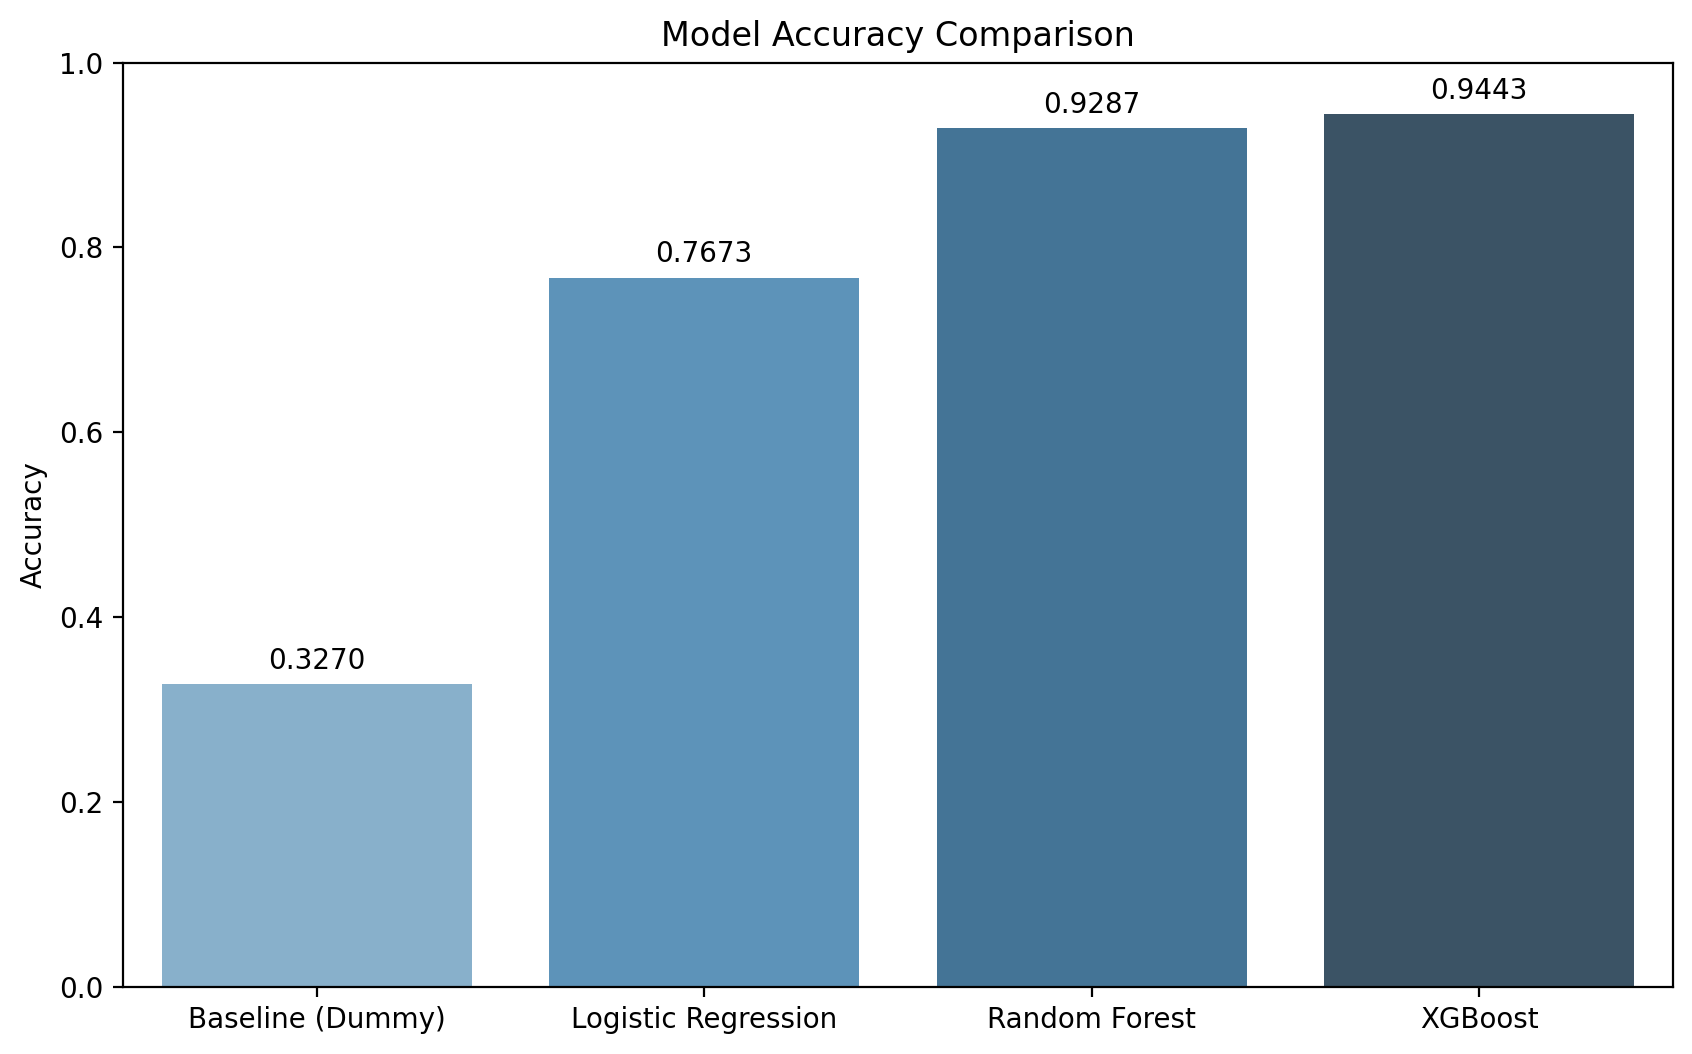

In [25]:
print("\nPlotting model comparison...")
models = ['Baseline (Dummy)', 'Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [acc_dummy, acc_logreg, acc_rf, acc_xgb]
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='Blues_d')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')
plt.show()

For interest: built a importance function to understand which features are most significant in both Random Forest and XGBoost models that may distinguish the ability to correctly predict


Random Forest Feature Importances:
               Feature  Importance
11                 az    0.129660
5               pfx_z    0.125985
4               pfx_x    0.083122
9                  ax    0.082224
0       release_speed    0.078963
13  release_spin_rate    0.074394
15          spin_axis    0.060354
7                 vy0    0.059800
12    effective_speed    0.056682
1       release_pos_x    0.044427
18          arm_angle    0.033540
3       release_pos_z    0.032989
10                 ay    0.025876
6                 vx0    0.023100
2       release_pos_y    0.020650
8                 vz0    0.015750
17            plate_z    0.015608
14  release_extension    0.015005
19           p_throws    0.011971
16            plate_x    0.009901


/tmp/ipython-input-4293080302.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances_rf, palette='Blues_d')


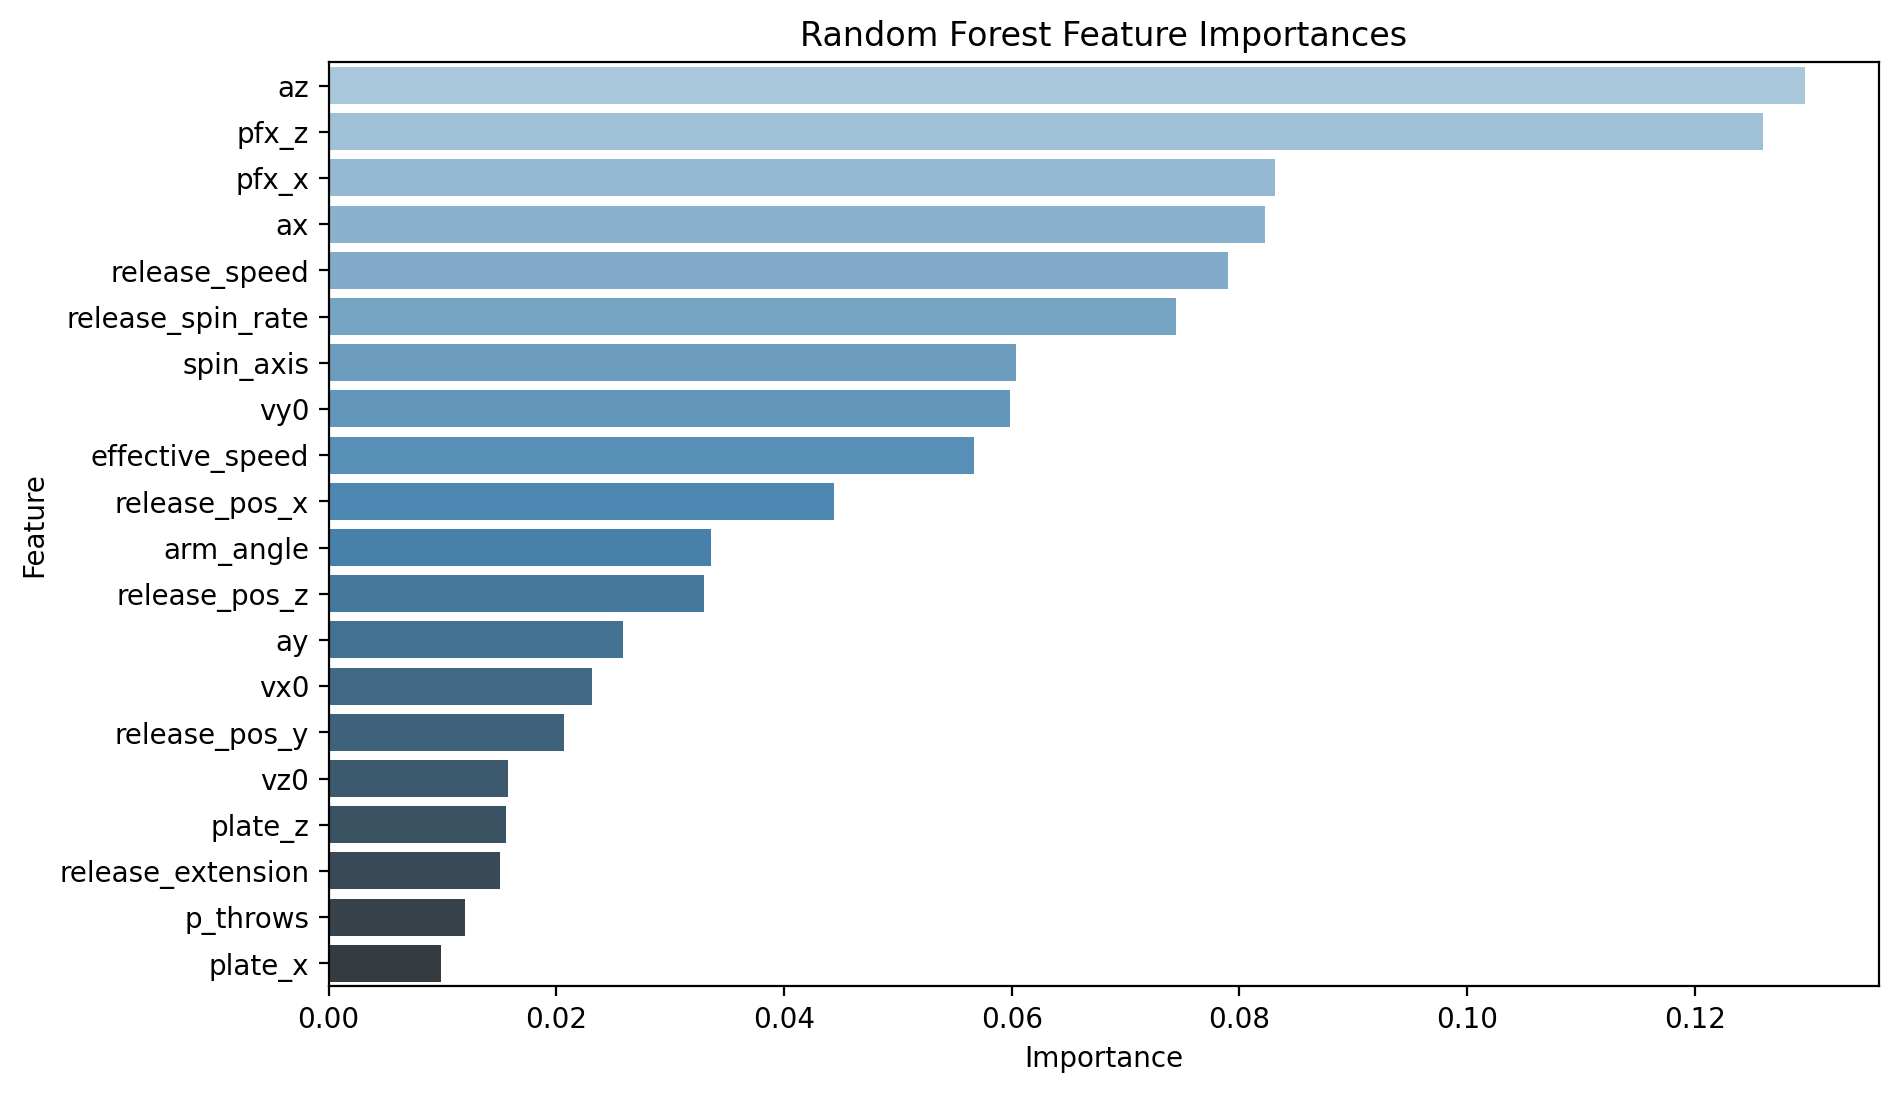

In [26]:
# Random Forest Feature Importances
importances_rf = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_})
importances_rf = importances_rf.sort_values('Importance', ascending=False)
print("\nRandom Forest Feature Importances:\n", importances_rf)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances_rf, palette='Blues_d')
plt.title('Random Forest Feature Importances')
plt.show()


XGBoost Feature Importances:
               Feature  Importance
11                 az    0.222814
0       release_speed    0.128898
19           p_throws    0.112645
5               pfx_z    0.107963
9                  ax    0.102854
13  release_spin_rate    0.059392
4               pfx_x    0.048090
7                 vy0    0.047290
15          spin_axis    0.042446
12    effective_speed    0.024205
1       release_pos_x    0.022201
18          arm_angle    0.016239
3       release_pos_z    0.013679
14  release_extension    0.013355
2       release_pos_y    0.009942
17            plate_z    0.008084
8                 vz0    0.007485
6                 vx0    0.004959
10                 ay    0.004706
16            plate_x    0.002752


/tmp/ipython-input-883189283.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances_xgb, palette='Blues_d')


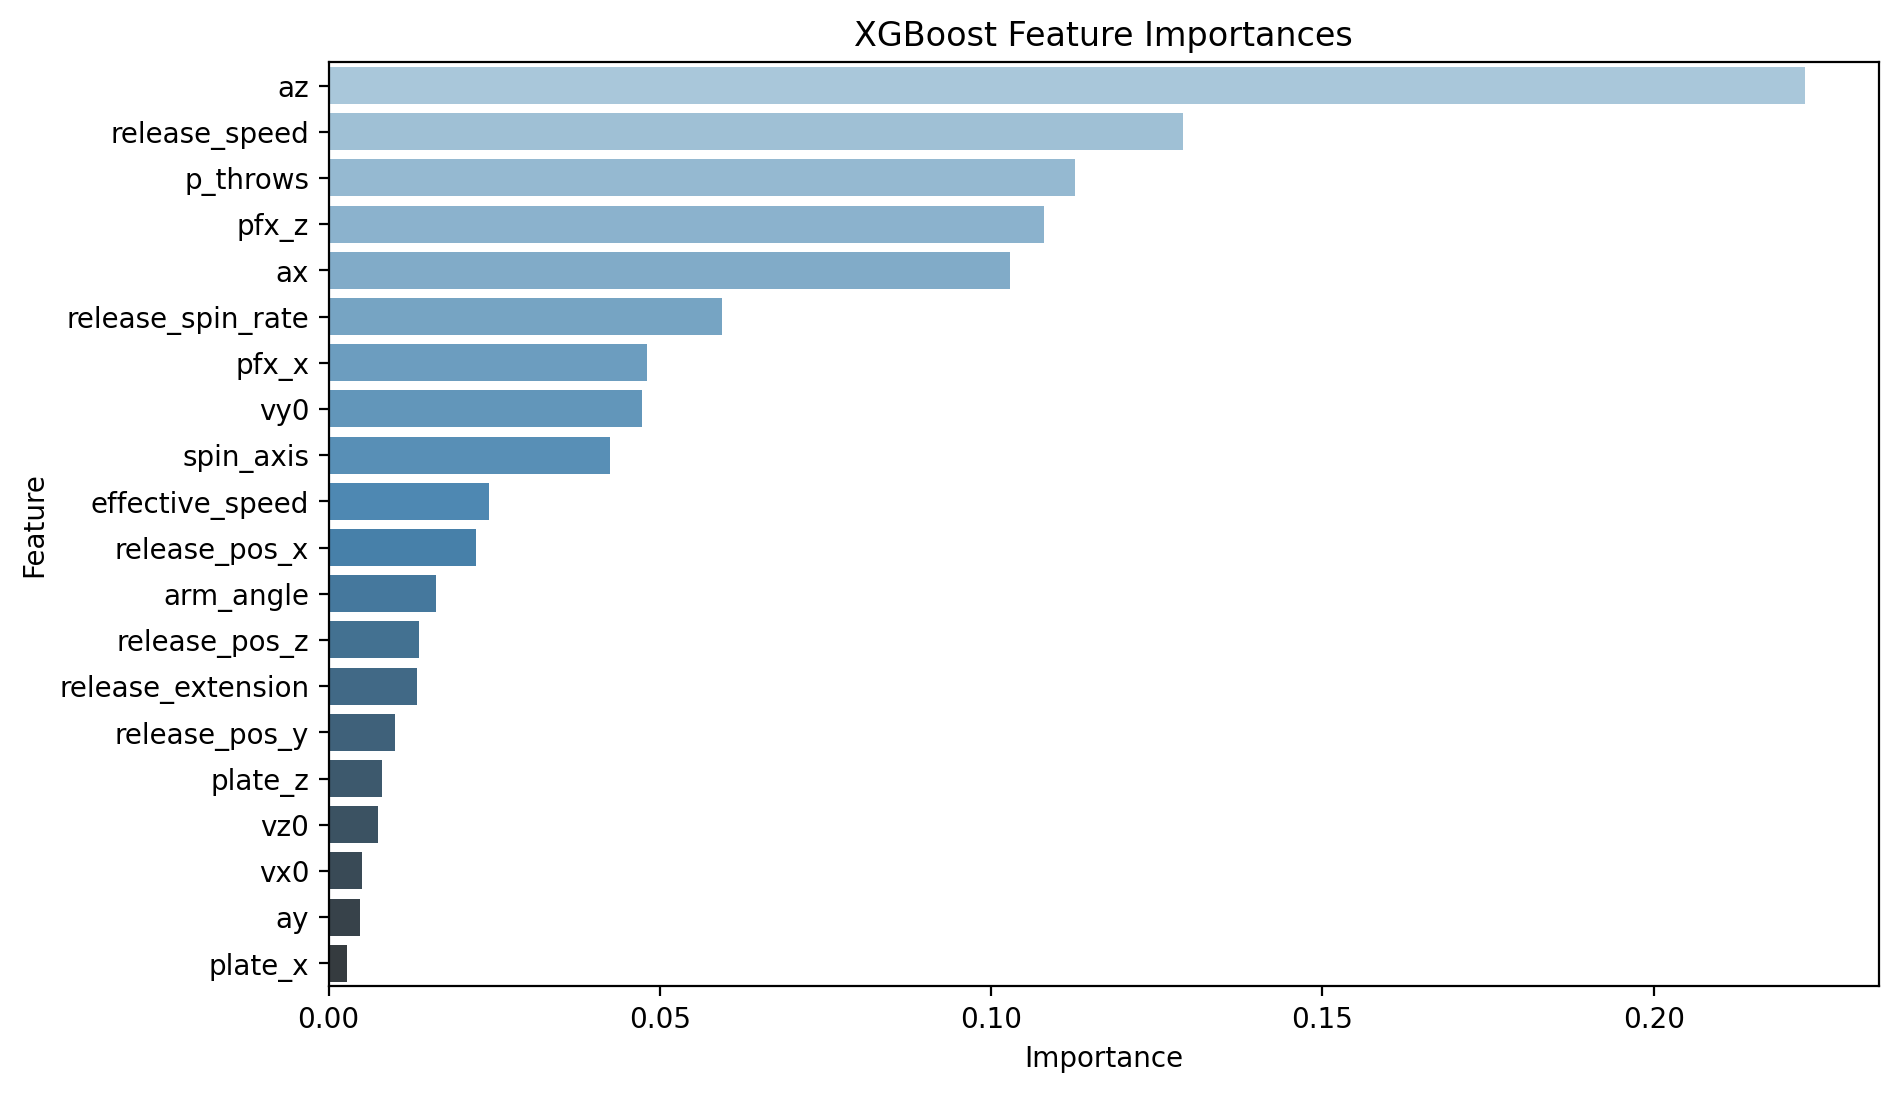

In [27]:
# XGBoost Feature Importances
importances_xgb = pd.DataFrame({'Feature': features, 'Importance': xgb_model.feature_importances_})
importances_xgb = importances_xgb.sort_values('Importance', ascending=False)
print("\nXGBoost Feature Importances:\n", importances_xgb)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances_xgb, palette='Blues_d')
plt.title('XGBoost Feature Importances')
plt.show()

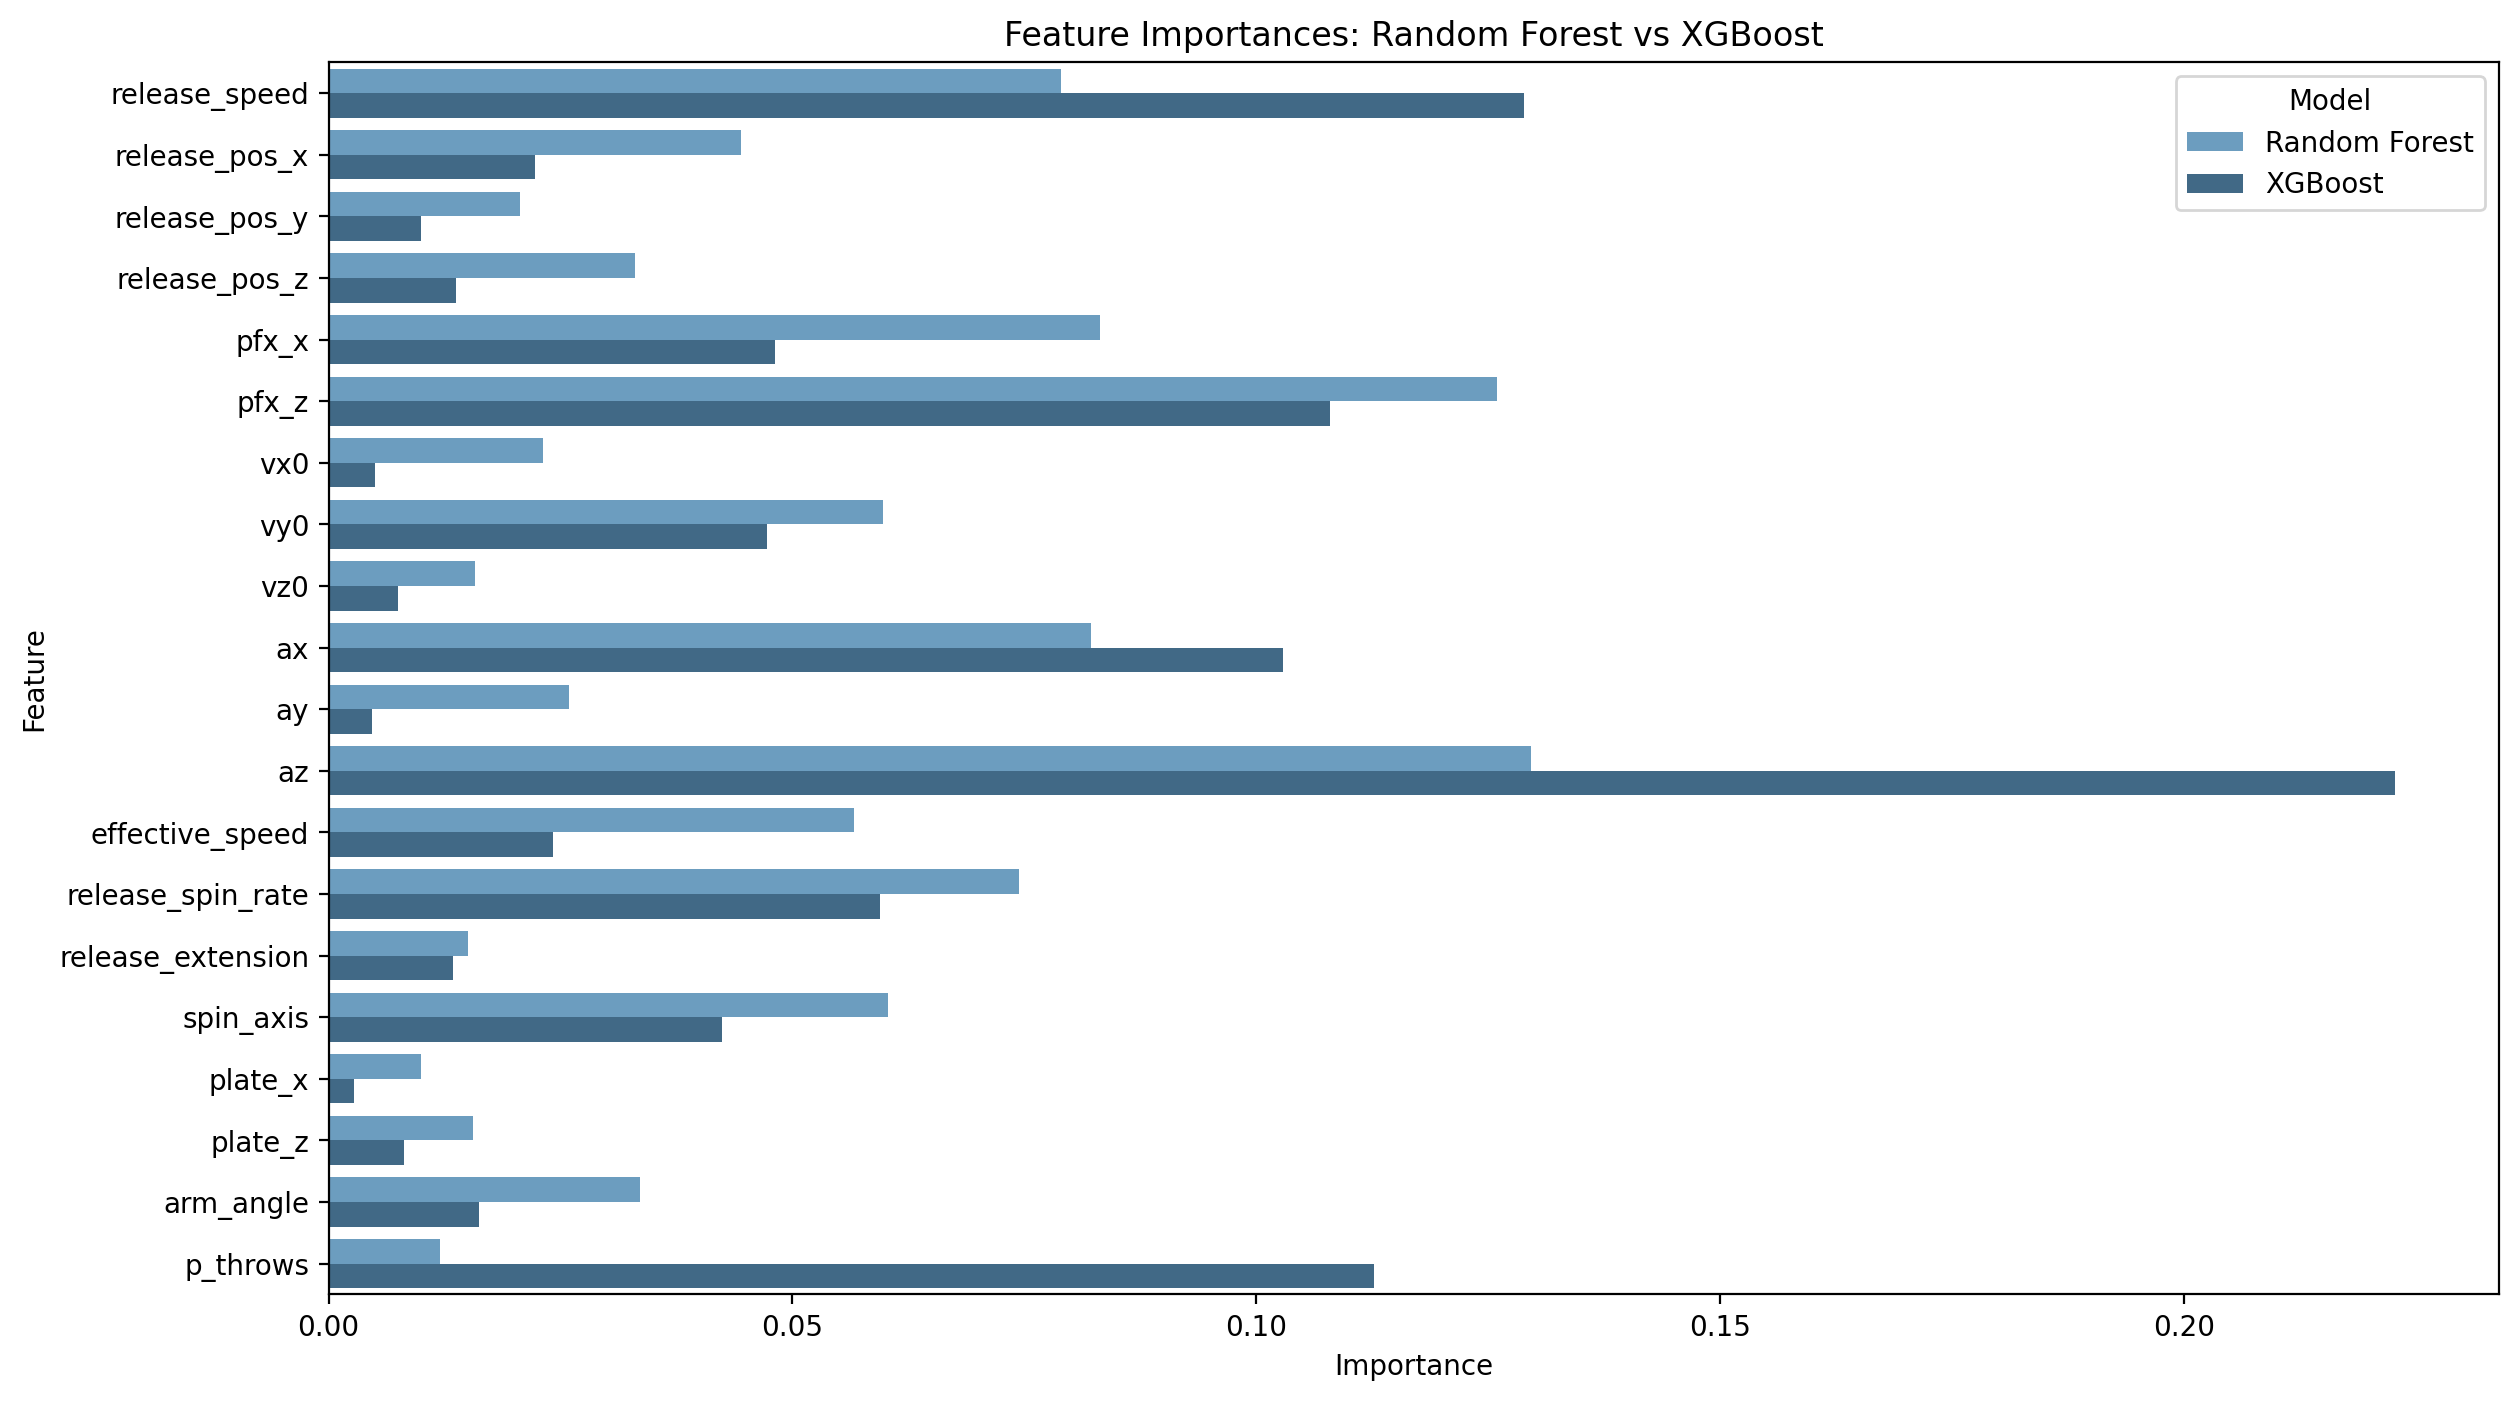

In [31]:
# Combine into one DataFrame
importances_combined = pd.concat([importances_rf, importances_xgb])

# Plot side-by-side comparison
plt.figure(figsize=(14, 8))
sns.barplot(
    data=importances_combined,
    x='Importance',
    y='Feature',
    hue='Model',
    palette='Blues_d'
)

plt.title('Feature Importances: Random Forest vs XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.legend(title='Model')
plt.show()

Another interesting finding is what each model determines the most predictive variable. Looking at just the Random Forest and XGBoost models (as these were the most accurate), the most predictable factors aree

- Random Boost - pfx_z (12.9%), az(12.8%), pfx_x (8.3%), ax (8.2%)

- XGBoost- az (22.7%), release_speed (12.3%), pfx_z (11.2%), P_throws (10.6%)

pfx_x = horizontal movement of the pitch from hand to home plate

pfx_z = vertical movement of the pitch from hand to home plate

ax = horizontal acceleratio of the ball moving to the plate

az = vertical acceleration of the ball moving to the plate

p_throws = distinguishing pitchers throwing hand (R:'0', L:'1')

Intuitively, we would think that the movement of the pitch and release speed would be the best predictors of pitch type as pitches differences can easily be broken down by their speed and how much they 'break'. Comparing the models, the significance of these variables are vastly different which may go into the overall accuracy


Created a Confusion Matrix for XG Boost true vs false responses

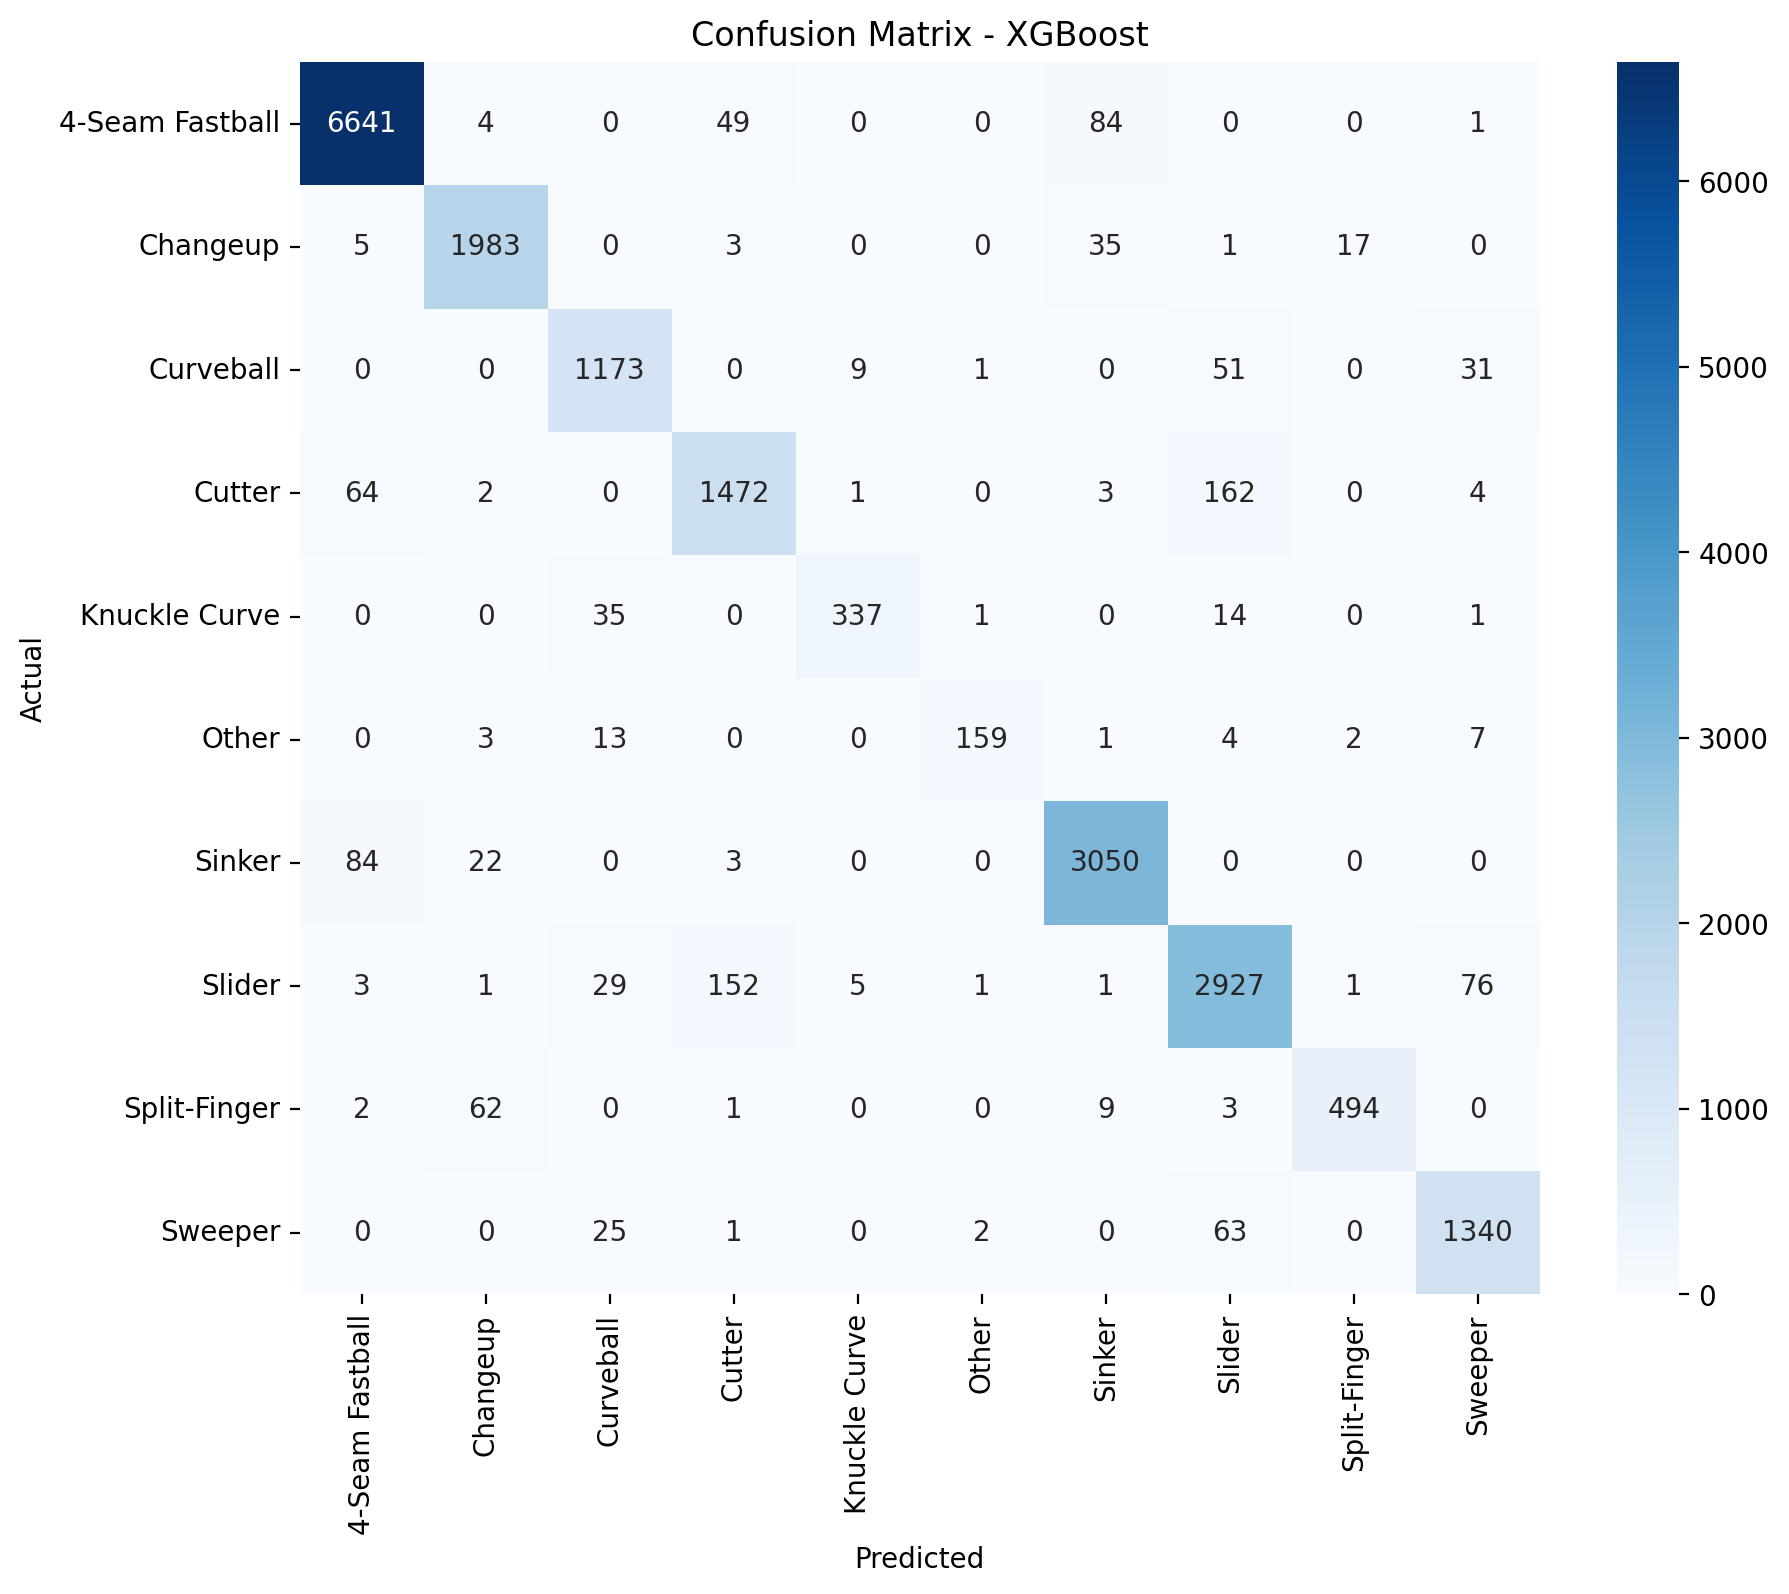

In [28]:
from sklearn.metrics import confusion_matrix # Import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix for XGboost
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

# Part 3: Interpret Model Outputs and Discuss Findings

**Discussion**

The analysis shows that tree-based models (like Random Forest and XGBoost) work better than Logistic Regression for classifying pitches, with accuracies around 80–90%. These models perform well because they can recognize more complex patterns in the data. For example, they do a good job at telling apart fastballs and sinkers, but sometimes struggle to separate sliders, sweepers, and cutters since those pitches move in similar ways.

The most important factors for predicting pitch type are how the ball moves sideways (pfx_x), how it moves up and down (pfx_z), how fast it’s thrown (release_speed), and how much it spins (release_spin_rate). However, the relative importance of these factors differs between Random Forest and XGBoost models. These features help distinguish pitches, for instance, curveballs usually drop more, and sliders tend to move sideways.

One challenge is that some pitch types are much rarer than others, which makes it harder for the model to predict them correctly. A fix could be giving the model more data on those rare pitches. This could be done by extending the timeline or (if looking at specific pitchers), add characteristics of their throwing style.